# Are the new neutral full traces different?

Compare `runs/fulltrace/*n` (old) with `runsNEW/fulltrace/*_N_*` (new). Each dot and each classifier example is **one complete run**, not an individual time sample. This is a small, exploratory batch comparison.

**Label caveat:** new `N` folders have `joy` in their metadata and prompt logs. We follow the requested folder designation, but these files do not verify that the actual prompts were neutral. Resolve this before interpreting the result as a neutral-versus-neutral comparison.


In [1]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'runs/fulltrace').is_dir())
COLORS = {'old': '#4477AA', 'new': '#EE7733'}
pd.set_option('display.max_columns', 20)


## Load and check the runs

Use the raw CSVs from both folders, applying the same processing. Perf values are interval counts, not cumulative counters. Sampling intervals vary, so compare **total counts / observed seconds**, rather than raw counts per row. Drop the first interval (startup) and any interval with missing/negative counters or non-increasing time. The analysis covers the recorded collector trace, including its short startup/tail; it does not claim exact request-window alignment.


In [2]:
events = ['core_power.throttle', 'tlb:tlb_flush', 'instructions', 'cycles']
rows, profiles = [], []
for batch, directory, pattern in [('old', 'runs', r'\d+_\d+n'), ('new', 'runsNEW', r'\d+_N_\d+')]:
    for folder in sorted((ROOT / directory / 'fulltrace').iterdir()):
        if not folder.is_dir() or not re.fullmatch(pattern, folder.name):
            continue
        meta = json.loads((folder / 'trace_meta.json').read_text())
        collector = json.loads((folder / 'collector_meta.json').read_text())
        log = json.loads((folder / 'prompt_log.json').read_text())
        raw = pd.read_csv(folder / 'perf_stat.csv')
        values = raw[events].apply(pd.to_numeric, errors='coerce')
        t = pd.to_numeric(raw.t_s, errors='coerce')
        dt = t.diff()
        valid = dt.gt(0) & np.isfinite(dt) & np.isfinite(values).all(axis=1) & values.ge(0).all(axis=1)
        v, seconds = values.loc[valid], dt.loc[valid]
        assert len(v) > 0 and meta['all_ok'] and all(p['ok'] for p in log), folder
        total, duration = v.sum(), seconds.sum()
        row = dict(batch=batch, run=folder.name, node=folder.name.split('_')[0],
                   label=meta['label'], model=meta['model_size'], prompts=meta['n_prompts'],
                   n_predict=meta['n_predict'], date=pd.to_datetime(meta['t_trace_start_ns'], unit='ns').date().isoformat(),
                   requested_interval_ms=collector['perf_interval_ms'], samples=len(v),
                   excluded_rows=len(raw)-len(v), coverage=duration/(t.iloc[-1]-t.iloc[0]),
                   interval_ms=seconds.median()*1000, duration_s=meta['total_trace_ms']/1000,
                   throttle_s=total['core_power.throttle']/duration,
                   tlb_s=total['tlb:tlb_flush']/duration,
                   instructions_s=total['instructions']/duration,
                   cycles_s=total['cycles']/duration,
                   ipc=total['instructions']/total['cycles'],
                   throttle_per_million_instructions=1e6*total['core_power.throttle']/total['instructions'])
        rows.append(row)
        # Equal progress bins: sum interval counts / sum interval lengths.
        bins = np.minimum(((t.loc[valid]-t.iloc[0])/(t.iloc[-1]-t.iloc[0])*40).astype(int), 39)
        binned = pd.DataFrame({'bin': bins, 'count': v['core_power.throttle'], 'seconds': seconds}).groupby('bin').sum()
        profiles.append((batch, folder.name, (binned.index.to_numpy()+0.5)/40, (binned['count']/binned.seconds).to_numpy()))
runs = pd.DataFrame(rows)
assert set(runs.batch) == {'old', 'new'}
display(runs.groupby('batch').agg(runs=('run','size'), nodes=('node','nunique'), first_date=('date','min'), last_date=('date','max')))
display(runs[['batch','run','label','model','prompts','n_predict','requested_interval_ms','interval_ms','excluded_rows','coverage']].round(4))
print('Shared node IDs:', sorted(set(runs.query("batch == 'old'").node) & set(runs.query("batch == 'new'").node)))


Shared node IDs: ['229']


,runs,nodes,first_date,last_date
batch,,,,
new,4,4,2026-09-09,2026-09-09
old,20,13,2026-05-04,2026-05-12


,batch,run,label,model,prompts,n_predict,requested_interval_ms,interval_ms,excluded_rows,coverage
0,old,222_1n,neutral,70b,20,50,1,8.8637,1,1.0
1,old,222_2n,neutral,70b,20,50,1,8.8465,1,1.0
2,old,224_1n,neutral,70b,20,50,1,8.7572,1,1.0
3,old,224_2n,neutral,70b,20,50,1,8.6034,1,1.0
4,old,226_1n,neutral,70b,20,50,1,8.7402,1,1.0
5,old,229_1n,neutral,70b,20,50,1,8.6486,1,1.0
6,old,229_2n,neutral,70b,20,50,1,8.8543,1,1.0
7,old,230_1n,neutral,70b,20,50,1,8.5901,1,1.0
8,old,230_2n,neutral,70b,20,50,1,8.6259,1,1.0
9,old,231_1n,neutral,70b,20,50,1,8.7501,1,1.0


## How large are the differences?

The table reports the median across runs and the percent change from old to new. Dots show all runs, so a group median cannot hide overlap or outliers. Throttle counts per million instructions partially account for workload volume; they do not remove all hardware or collection confounds.


batch,new,old,change_%
throttle_s,1.262099e+09,1.157705e+09,9.017
tlb_s,1.368980e+04,1.330031e+04,2.928
instructions_s,9.880674e+10,9.827213e+10,0.544
cycles_s,1.266747e+11,1.299784e+11,-2.542
ipc,7.790000e-01,7.580000e-01,2.817
throttle_per_million_instructions,1.274001e+04,1.170924e+04,8.803
duration_s,1.146333e+03,1.151347e+03,-0.436
interval_ms,8.562000e+00,8.667000e+00,-1.210


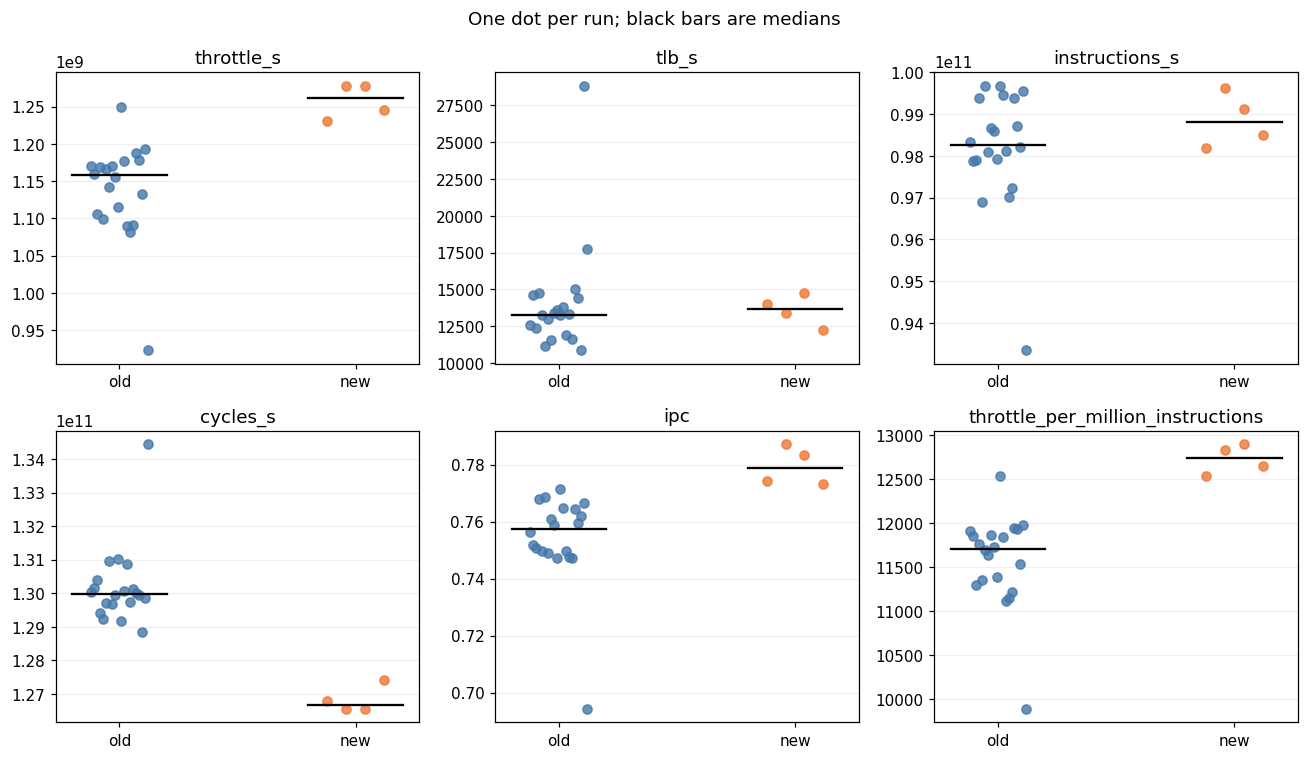

In [3]:
features = ['throttle_s', 'tlb_s', 'instructions_s', 'cycles_s', 'ipc', 'throttle_per_million_instructions']
medians = runs.groupby('batch')[features + ['duration_s', 'interval_ms']].median().T
medians['change_%'] = 100*(medians['new']/medians['old']-1)
display(medians.round(3))
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, feature in zip(axes.flat, features):
    for i, batch in enumerate(['old','new']):
        vals = runs.loc[runs.batch.eq(batch), feature].to_numpy()
        ax.scatter(i + np.linspace(-.12,.12,len(vals)), vals, color=COLORS[batch], alpha=.8)
        ax.plot([i-.2,i+.2], [np.median(vals)]*2, color='black')
    ax.set(xticks=[0,1], xticklabels=['old','new'], title=feature)
    ax.grid(axis='y', alpha=.2)
fig.suptitle('One dot per run; black bars are medians')
plt.tight_layout()
plt.show()


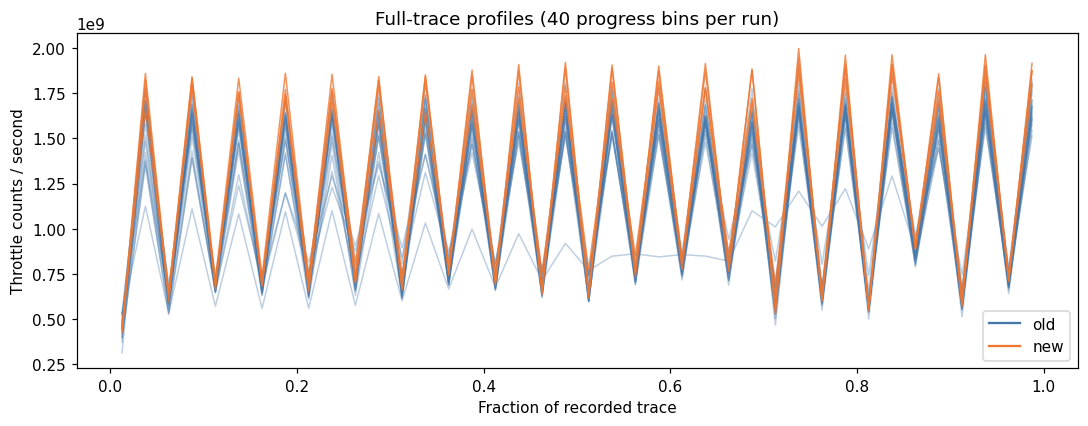

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for batch, name, progress, rate in profiles:
    ax.plot(progress, rate, color=COLORS[batch], alpha=.35 if batch == 'old' else .8, linewidth=1)
for batch in COLORS:
    ax.plot([], [], color=COLORS[batch], label=batch)
ax.set(xlabel='Fraction of recorded trace', ylabel='Throttle counts / second', title='Full-trace profiles (40 progress bins per run)')
ax.legend()
plt.tight_layout()
plt.show()


## Can a simple classifier tell them apart?

A fixed, class-balanced logistic regression predicts old/new using the six features above. For each prediction, **all runs with that node ID are held out**. Scaling is learned only on the training data. Dates, names, labels and duration are not classifier inputs. Balanced accuracy averages old and new recall; always guessing old scores 50%, despite the unequal group sizes. This tests a simple summary-based separator, not every possible difference in trace shape.

With only four new runs, each new mistake changes new recall by 25 percentage points. The result is exploratory: collection date and batch coincide, most nodes differ, and there is no independent future batch for confirmation.


In [5]:
X = np.log1p(runs[features].to_numpy())
y = runs.batch.eq('new').astype(int).to_numpy()
model = make_pipeline(StandardScaler(), LogisticRegression(C=1, class_weight='balanced', max_iter=2000, random_state=0))
cv = LeaveOneGroupOut()
pred = cross_val_predict(model, X, y, groups=runs.node, cv=cv)
score = balanced_accuracy_score(y, pred)
cm = confusion_matrix(y, pred, labels=[0,1])
print(f'Node-held-out balanced accuracy: {score:.1%} (baseline: 50%)')
display(pd.DataFrame(cm, index=['actual old','actual new'], columns=['predicted old','predicted new']))
check = runs[['batch','run']].copy()
check['prediction'] = np.where(pred, 'new', 'old')
check['correct'] = pred == y
display(check)


Node-held-out balanced accuracy: 97.5% (baseline: 50%)


,predicted old,predicted new
actual old,19,1
actual new,0,4


,batch,run,prediction,correct
0,old,222_1n,old,True
1,old,222_2n,old,True
2,old,224_1n,old,True
3,old,224_2n,old,True
4,old,226_1n,old,True
5,old,229_1n,old,True
6,old,229_2n,old,True
7,old,230_1n,old,True
8,old,230_2n,old,True
9,old,231_1n,old,True


## Explanation of the results

The following summary is generated from the data, so it updates when the notebook is rerun.


In [6]:
old_recall, new_recall = cm[0,0]/cm[0].sum(), cm[1,1]/cm[1].sum()
largest = medians.loc[features, 'change_%'].abs().idxmax()
verdict = ('The simple model shows some separation in these recorded batches.' if score > .6 else
           'The simple model does not show convincing separation in these recorded batches.')
display(Markdown(f"""
- **Differences:** the largest relative median change among the six features is `{largest}` ({medians.loc[largest, 'change_%']:+.1f}%). Throttle rate changes by {medians.loc['throttle_s','change_%']:+.1f}%; throttle per million instructions changes by {medians.loc['throttle_per_million_instructions','change_%']:+.1f}%.
- **Distinguishability:** balanced accuracy is **{score:.1%}**, with {old_recall:.0%} of old runs and {new_recall:.0%} of new runs correctly identified. {verdict} This is a descriptive assessment, not a significance test.
- **Interpretation:** differences may reflect hardware, collection date, workload, or setup. They do not establish a change caused by neutral content. Overlapping plots or weak prediction also do not prove the batches are equivalent.
- **Main limitations:** only {sum(y)} new runs; repeated old runs on some nodes; mostly different node sets; new `N` metadata says `joy`; prompt text is absent from these logs. Confirm the prompt identity and collect more old/new runs on the same nodes with interleaved collection before making a stronger claim.
"""))



- **Differences:** the largest relative median change among the six features is `throttle_s` (+9.0%). Throttle rate changes by +9.0%; throttle per million instructions changes by +8.8%.
- **Distinguishability:** balanced accuracy is **97.5%**, with 95% of old runs and 100% of new runs correctly identified. The simple model shows some separation in these recorded batches. This is a descriptive assessment, not a significance test.
- **Interpretation:** differences may reflect hardware, collection date, workload, or setup. They do not establish a change caused by neutral content. Overlapping plots or weak prediction also do not prove the batches are equivalent.
- **Main limitations:** only 4 new runs; repeated old runs on some nodes; mostly different node sets; new `N` metadata says `joy`; prompt text is absent from these logs. Confirm the prompt identity and collect more old/new runs on the same nodes with interleaved collection before making a stronger claim.
